In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from NanoparticlesSAM.particle_stats import *
from NanoparticlesSAM.particle_seg import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [3]:
foldername = 'results/20250324-sam2/'
pickels = glob.glob(f'{foldername}/*pkl')

df_list = []
for file in pickels:
    df_list.append(pd.read_pickle(file))

df = pd.concat(df_list)
#df['nm_per_pixel']  = df['nm_estimated_radius'] / df['estimated_radius']

In [4]:
print(df.shape)
df.head()

(995, 21)


,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,...,estimated_radius,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment,nm_per_pixel
0,"[[False, False, False, False, False, False, Fa...",27416,"[245.0, 315.0, 186.0, 186.0]",0.992188,"[[300.0, 345.0]]",0.989878,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",749,27416.0,...,93.417257,"(300.0, 345.0)",189.842040,183.989182,118.651275,116.771571,229.986477,A2-01,A2-1h (1),1.25
1,"[[False, False, False, False, False, False, Fa...",27407,"[245.0, 315.0, 357.0, 186.0]",0.992188,"[[260.0, 375.0]]",0.989798,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",749,27404.0,...,93.401922,"(260.0, 375.0)",189.612763,184.118912,118.507977,116.752403,230.148640,A2-01,A2-1h (1),1.25
2,"[[False, False, False, False, False, False, Fa...",28094,"[659.0, 304.0, 190.0, 189.0]",0.988281,"[[740.0, 315.0]]",0.990155,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",763,28094.0,...,94.565310,"(740.0, 315.0)",193.209731,187.528549,120.756082,118.206638,234.410686,A2-01,A2-1h (1),1.25
3,"[[False, False, False, False, False, False, Fa...",27833,"[547.0, 444.0, 184.0, 192.0]",0.988281,"[[620.0, 465.0]]",0.984989,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",755,27832.0,...,94.125018,"(620.0, 465.0)",198.736006,185.113266,124.210004,117.656273,231.391582,A2-01,A2-1h (1),1.25
4,"[[False, False, False, False, False, False, Fa...",28092,"[356.0, 465.0, 189.0, 189.0]",0.988281,"[[420.0, 495.0]]",0.988317,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",761,28092.0,...,94.561944,"(420.0, 495.0)",194.257561,183.337051,121.410976,118.202430,229.171314,A2-01,A2-1h (1),1.25


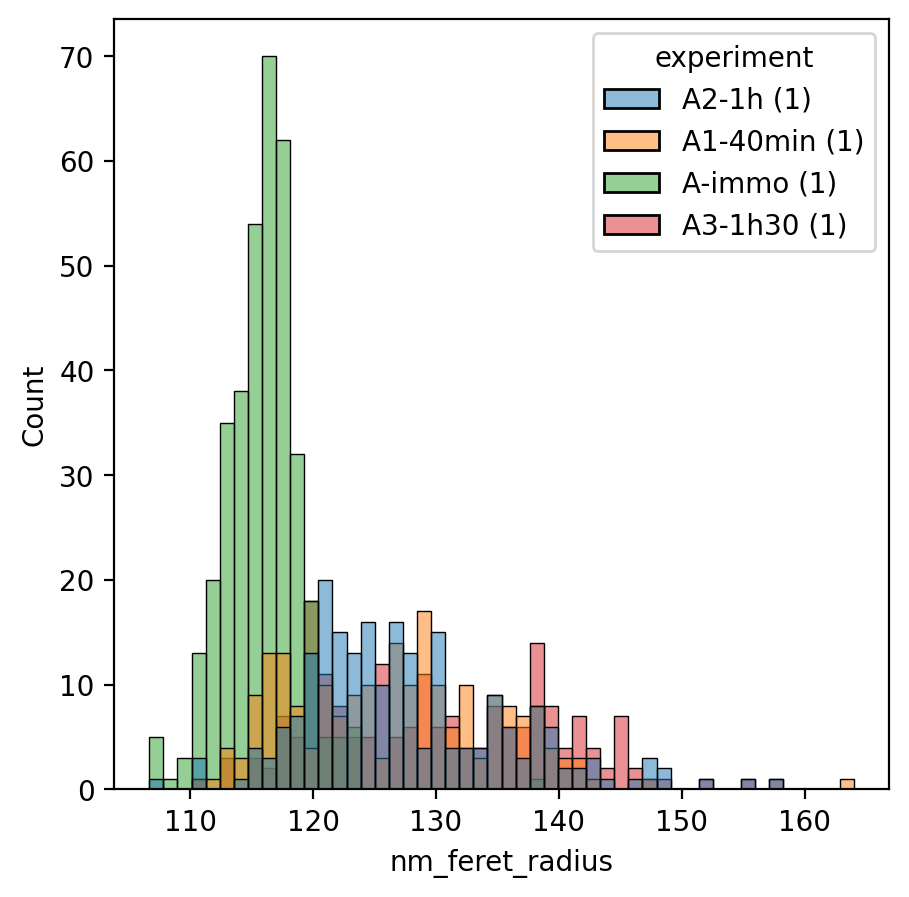

In [5]:
plt.figure(figsize=(5,5), dpi=200)
sns.histplot(data=df, x='nm_feret_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [6]:
#exclusion_list = ['A1-01', 'A1-04', 'A1-02', 'B3-01','B2-05','B2-04','B2-03','B2-02'] #20250224
#exclusion_list = [ 'A1-04', 'A1-12', 'A1-17','A1-18','A1-19', 'A2-08', 'A3-15', 'A3-16', 'A3-17', 'A3-20'] #20250324
exclusion_list = [] #20250324-sam2

In [7]:
df_exluded = df[~df['img_name'].isin(exclusion_list)]
df_exluded.shape

(995, 21)

In [8]:
df_exluded = df_exluded.query("circularity > 0.65")
df_exluded.shape

(995, 21)

In [9]:
df_exluded['hough_radius'] = df_exluded.apply(lambda x: get_hough_radius(x['smooth_mask'], 
                                                                           dp=2, 
                                                                           nm_min_radius=70, 
                                                                           nm_max_radius=150, 
                                                                           nm_per_pixel=x['nm_per_pixel'], 
                                                                           convert_to_nm=True), axis=1)

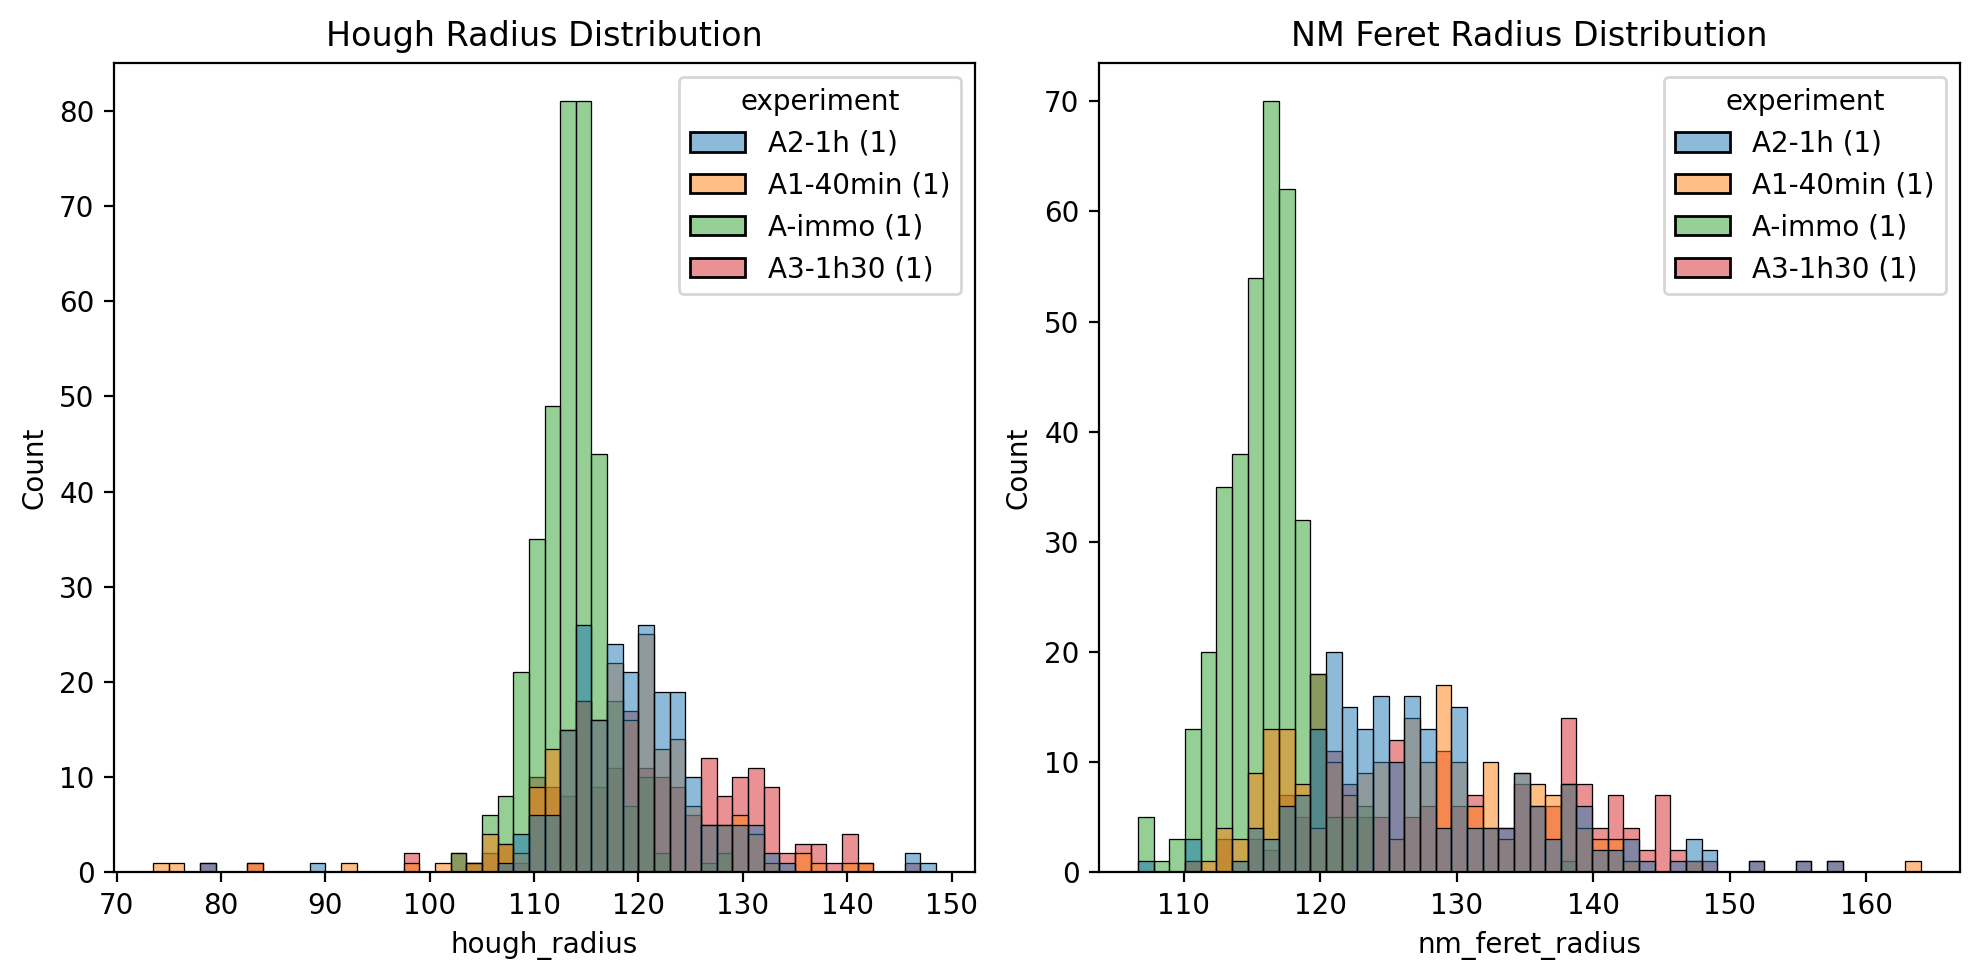

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=200)

sns.histplot(data=df_exluded.dropna(), x='hough_radius', hue='experiment', bins=50, ax=axes[0])
axes[0].set_title("Hough Radius Distribution")

sns.histplot(data=df_exluded.dropna(), x='nm_feret_radius', hue='experiment', bins=50, ax=axes[1])
axes[1].set_title("NM Feret Radius Distribution")
plt.tight_layout()

# Save the figure
plt.savefig(f'{foldername}/unfiltered_measurements')
plt.show()

In [11]:
#filter_quantity =  'hough_radius' 
#filter_quantity = 'nm_feret_radius' 

def filter_multiple(df, filters):
    '''quantile filtering for multiple filters'''
    for filter_quantity in filters:
        if filter_quantity in df.columns:
            q5, q95 = df[filter_quantity].quantile([0.05, 0.95])
            df = df[(df[filter_quantity] < q95) & (df[filter_quantity] > q5)]
        else:
            print(f'{filter_quantity} not found in dataframe')
    return df

df_filtered = filter_multiple(df_exluded, ['nm_feret_radius', 'hough_radius'])
df_filtered.shape

(802, 22)

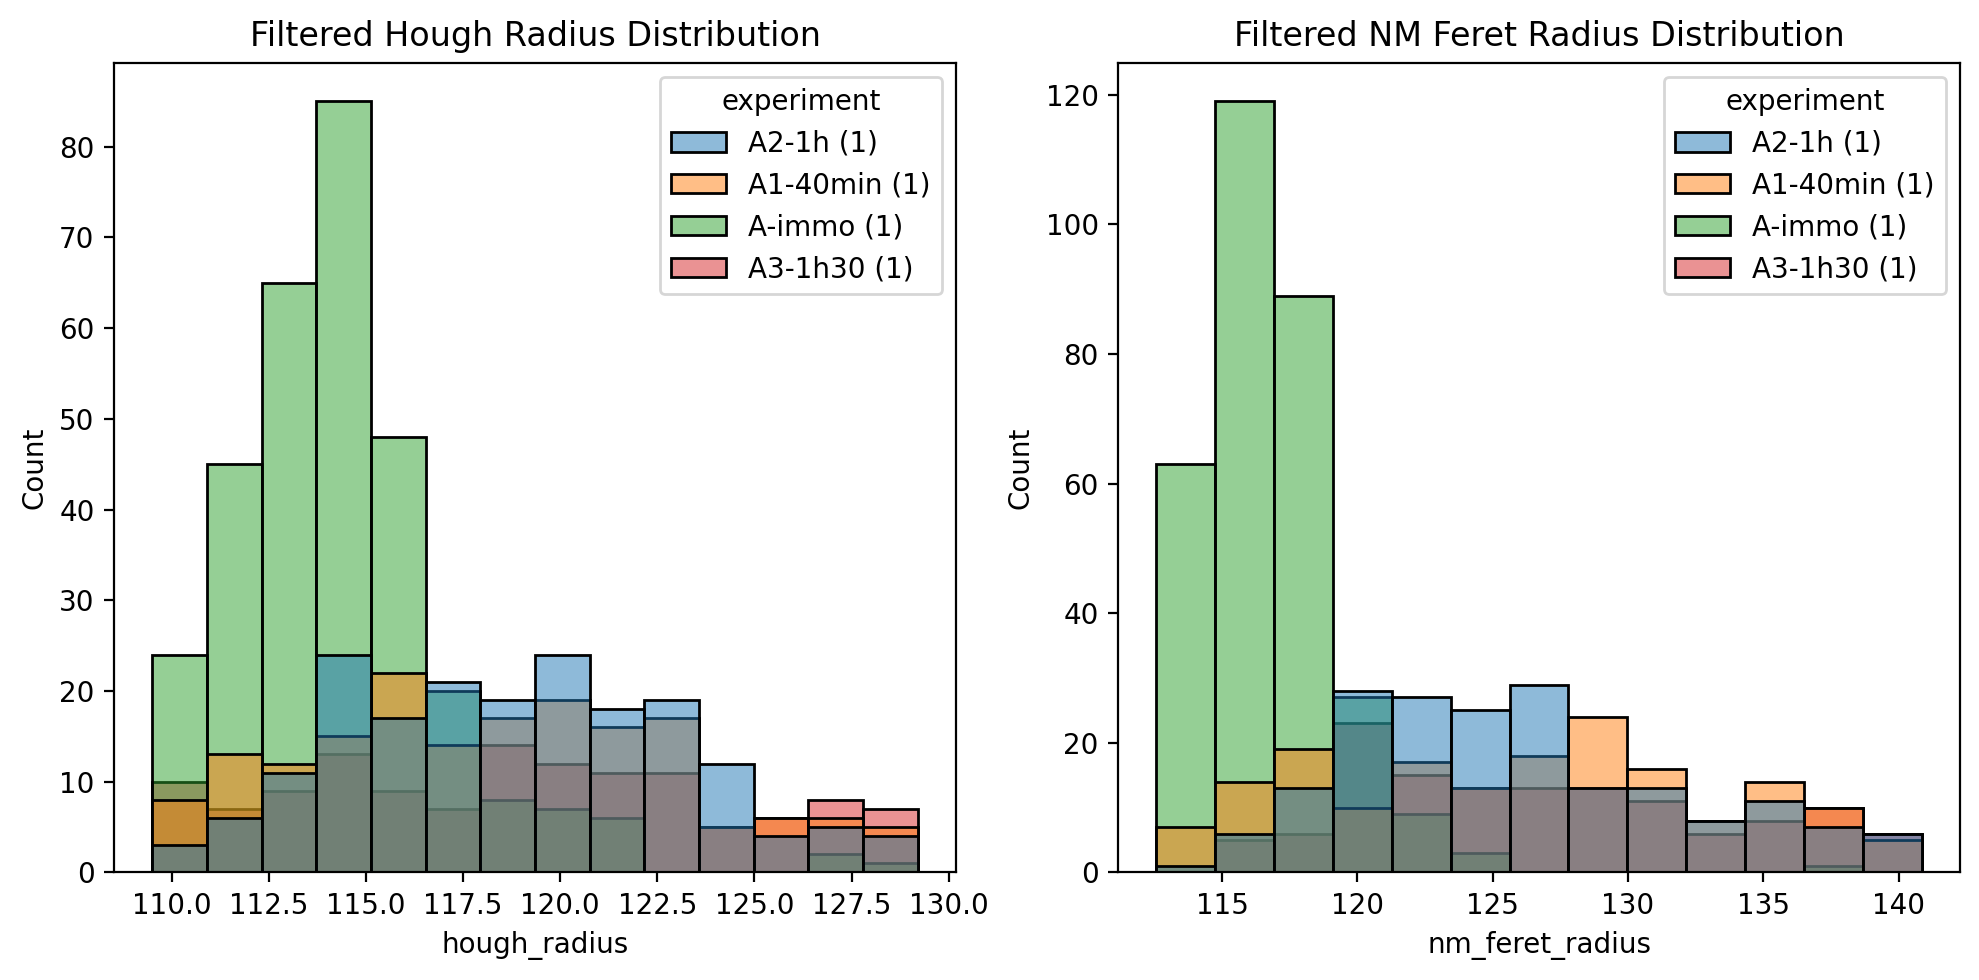

In [12]:
plot_df = df_filtered.dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=200)

sns.histplot(data=plot_df, x='hough_radius', hue='experiment', ax=axes[0])
axes[0].set_title("Filtered Hough Radius Distribution")

sns.histplot(data=plot_df, x='nm_feret_radius', hue='experiment', ax=axes[1])
axes[1].set_title("Filtered NM Feret Radius Distribution")

plt.tight_layout()

plt.savefig(f'{foldername}/filtered_particle_measurements')
plt.show()


<Figure size 1000x1000 with 0 Axes>

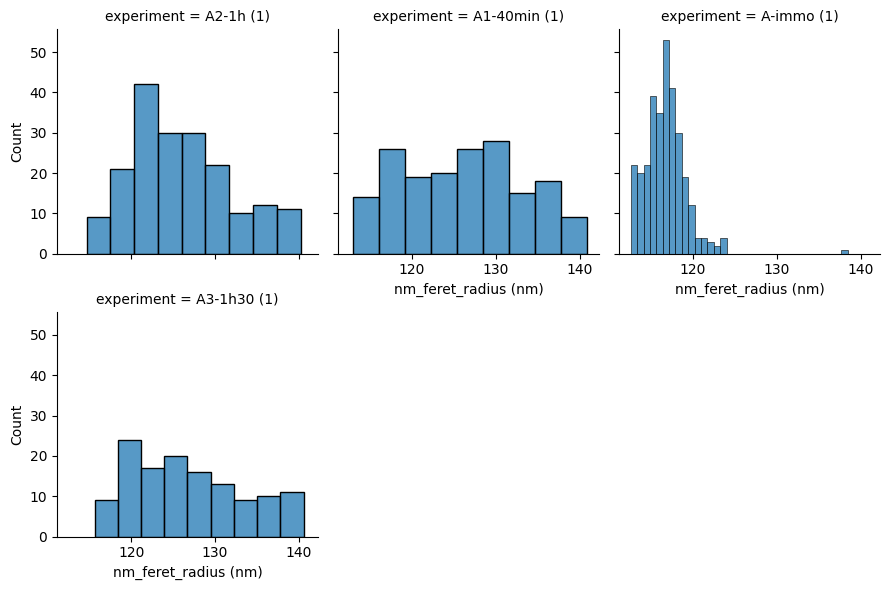

In [13]:
filter_quantity = 'nm_feret_radius'

plt.figure(figsize=(5,5), dpi=200)
g = sns.FacetGrid(plot_df, col='experiment', col_wrap=3)
g.map(sns.histplot, filter_quantity)
g.set_axis_labels(f"{filter_quantity} (nm)", "Count")
plt.savefig(f'{foldername}/histogram-grid')

In [43]:
df_filtered['avg'] = (df_filtered.hough_radius + df_filtered.nm_feret_radius)/2

In [44]:
experiment_df = df_filtered.reset_index().pivot(columns='experiment', values=['hough_radius', 'nm_feret_radius', 'avg'])
experiment_df = experiment_df.apply(lambda x: pd.Series(x.dropna().values))
#experiment_df = remove_outliers_df(experiment_df)
experiment_df.head()

hough_radius                                    nm_feret_radius  \
experiment   A-immo (1) A1-40min (1) A2-1h (1) A3-1h30 (1)      A-immo (1)   
0                114.00       115.00    117.25      129.00      116.256720   
1                111.00       115.25    114.50      125.25      115.888214   
2                112.50       119.25    119.00      128.50      116.520183   
3                112.50       118.00    114.25      123.00      117.197083   
4                113.75       116.50    118.75      122.00      113.636619   

                                                        avg               \
experiment A1-40min (1)   A2-1h (1) A3-1h30 (1)  A-immo (1) A1-40min (1)   
0            117.924764  118.651275  138.103788  115.128360   116.462382   
1            118.389255  118.507977  137.820649  113.444107   116.819627   
2            122.907486  120.756082  137.683117  114.510092   121.078743   
3            122.719828  124.210004  128.617954  114.848541   120.359914   
4            121.476914  121.410976  128.239278  113.693310   118.988457   

                                    
experiment   A2-1h (1) A3-1h30 (1)  
0           117.950637  133.551894  
1           116.503989  131.535324  
2           119.878041  133.091558  
3           119.230002  125.808977  
4           120.080488  125.119639

In [45]:
experiment_df.describe().to_excel(f'{foldername}/individual-particle-analysis.xlsx')
experiment_df.describe()

hough_radius                                      nm_feret_radius  \
experiment   A-immo (1) A1-40min (1)   A2-1h (1) A3-1h30 (1)      A-immo (1)   
count        311.000000   175.000000  187.000000  129.000000      311.000000   
mean         114.250000   118.332857  118.848930  118.906435      116.720620   
std            2.790393     4.723945    4.225289    5.397419        2.532926   
min          109.500000   109.500000  109.500000  109.668007      112.571158   
25%          112.500000   115.000000  115.250000  114.996002      115.282432   
50%          114.000000   118.000000  118.750000  118.991997      116.640808   
75%          115.500000   121.375000  122.000000  123.000000      117.916483   
max          128.500000   129.000000  128.750000  129.204010      138.430093   

                                                        avg               \
experiment A1-40min (1)   A2-1h (1) A3-1h30 (1)  A-immo (1) A1-40min (1)   
count        175.000000  187.000000  129.000000  311.000000   175.000000   
mean         126.102715  125.898314  126.850723  115.485310   122.217786   
std            7.159751    6.011653    6.644588    2.323883     5.459734   
min          112.960862  114.690480  115.637283  111.446136   111.274504   
25%          120.384295  121.203275  121.173164  113.903257   117.850878   
50%          126.503458  124.607195  125.670433  115.166148   122.731047   
75%          131.275291  129.733799  131.625950  116.695289   126.136415   
max          140.852594  140.184031  140.549846  126.215046   133.349872   

                                    
experiment   A2-1h (1) A3-1h30 (1)  
count       187.000000  129.000000  
mean        122.373622  122.878579  
std           4.698122    5.375403  
min         112.285655  112.930552  
25%         118.778079  117.831341  
50%         122.120373  123.173448  
75%         125.878499  126.528198  
max         133.752276  133.758599

In [46]:
method =  'hough_radius' 
method = 'nm_feret_radius' 
method = 'avg' 


analysis_df = analyze_samples(experiment_df[method], 'A-immo (1)', alpha=0.01)
analysis_df.to_csv(f'{foldername}/shield-analysis.csv')
analysis_df.to_excel(f'{foldername}/shield-analysis.xlsx')
analysis_df

,A1-40min (1),A2-1h (1),A3-1h30 (1)
thickness,6.732476,6.888312,7.393269
CI_lower,5.606287,5.932952,6.111321
CI_upper,7.858666,7.843673,8.675216
p_value,0.0,0.0,0.0
significance,Significant,Significant,Significant
significance_level,99.5,99.5,99.5
SEM,0.433244,0.367966,0.491281
DOF,210.059614,241.615343,148.247512
N_sample,175,187,129
N_ref,311,311,311


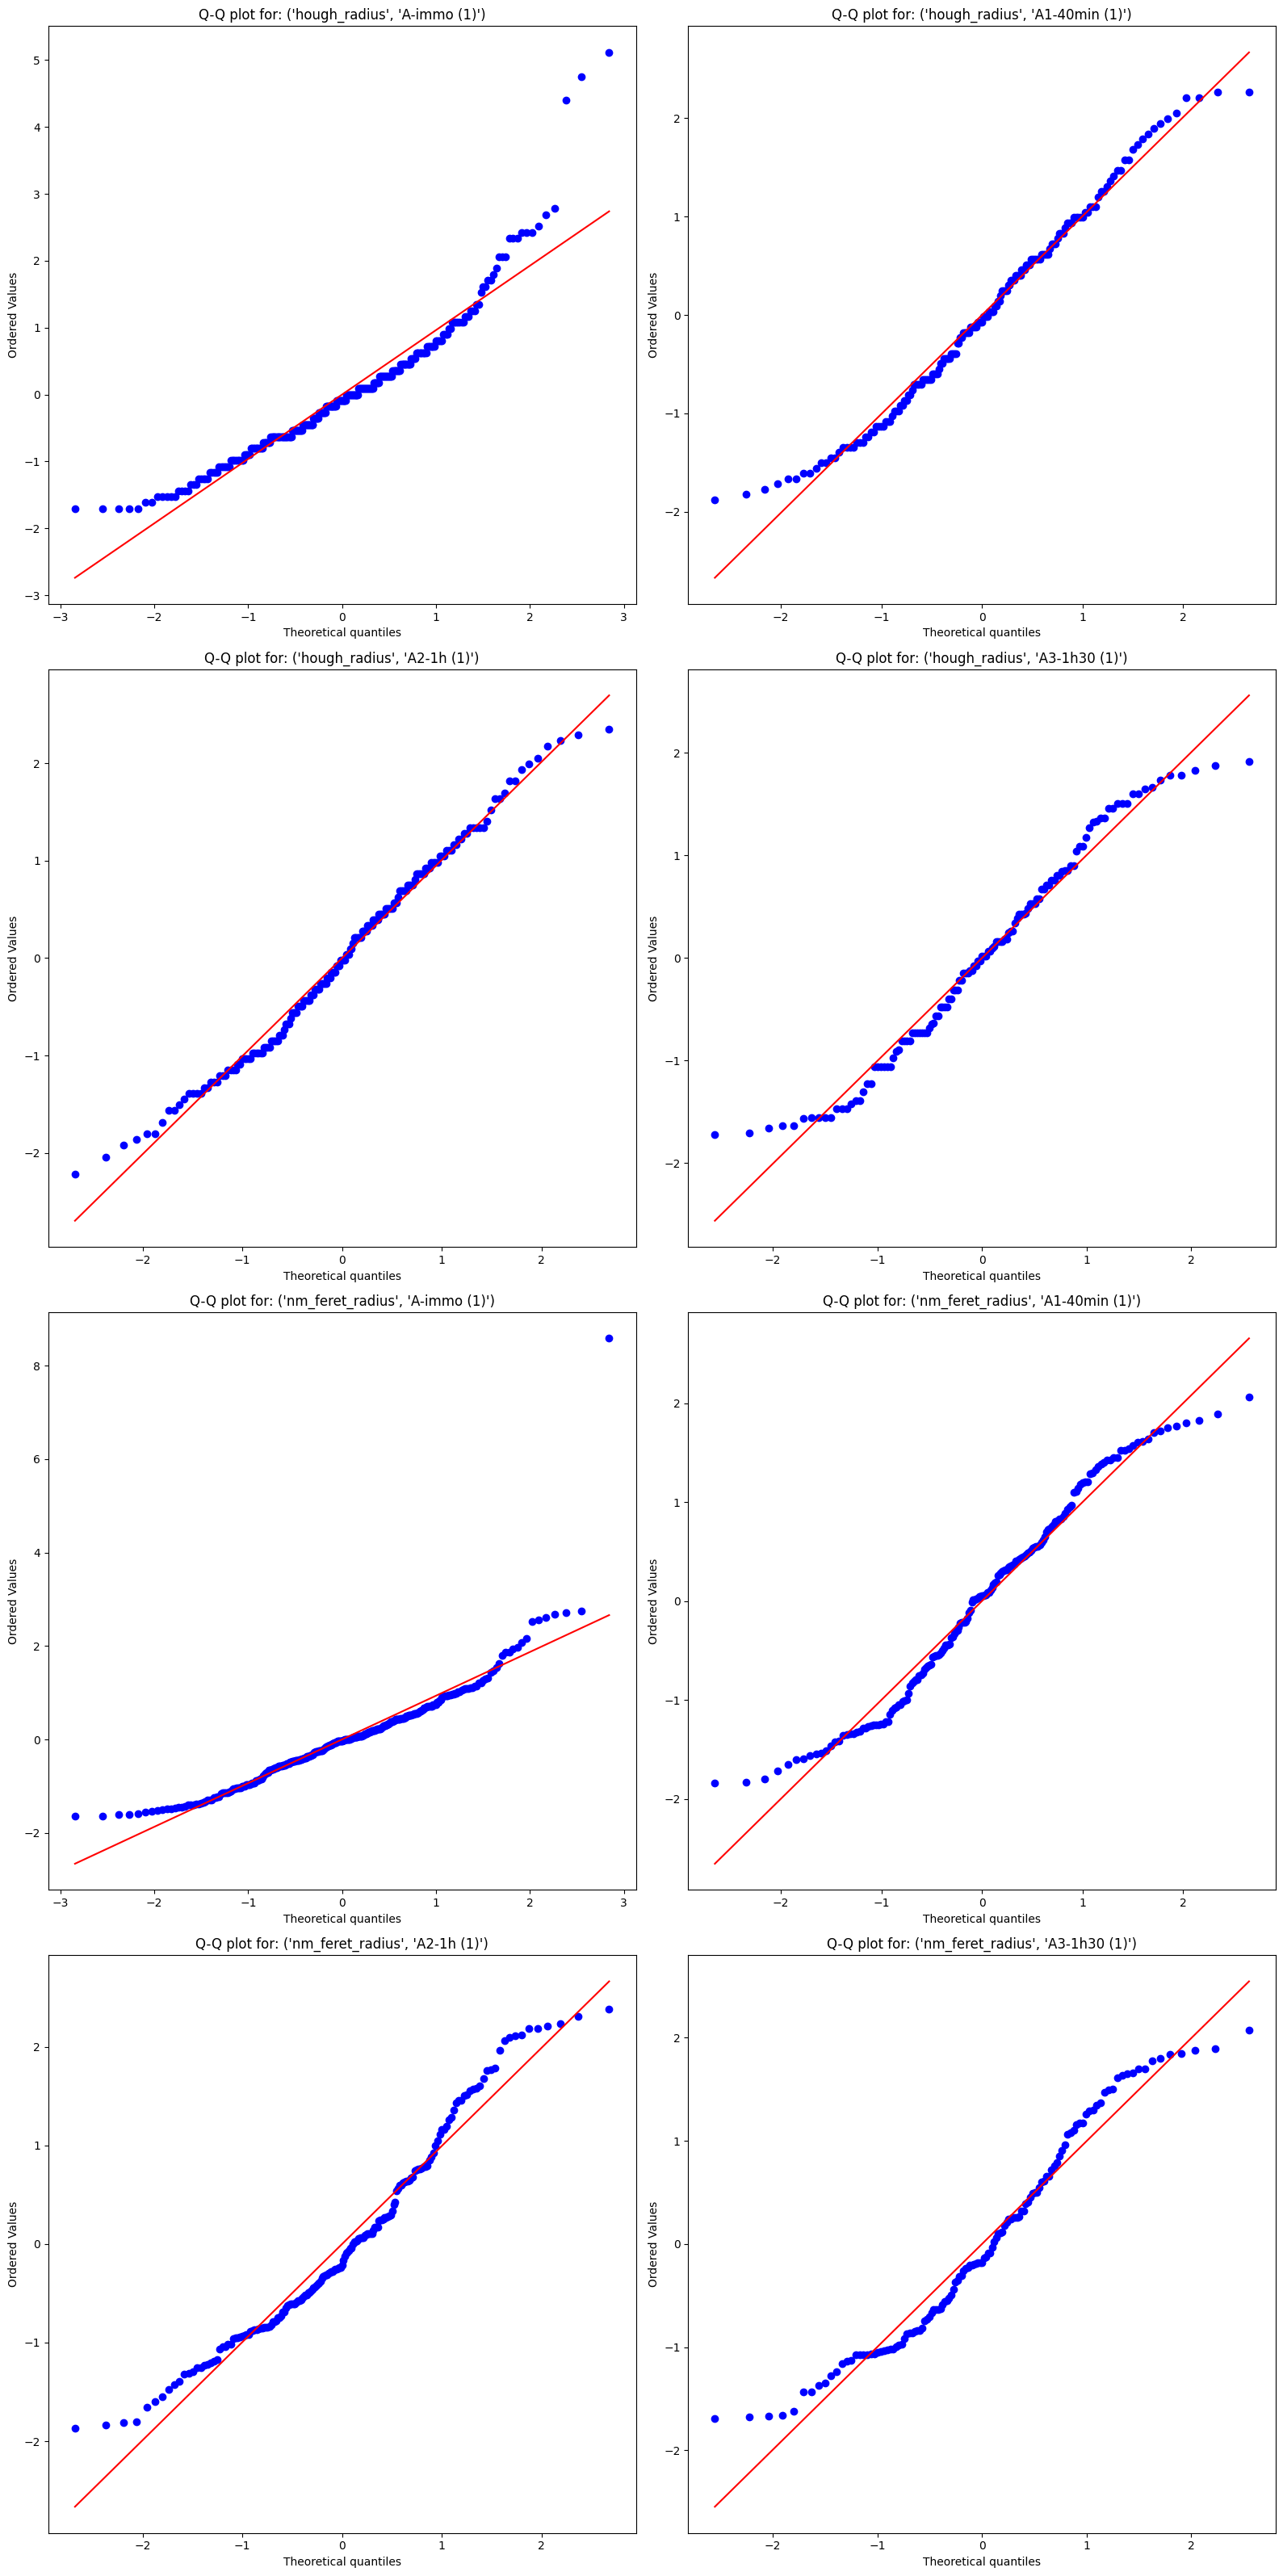

<Figure size 640x480 with 0 Axes>

In [30]:
plot_quantiles(experiment_df, foldername)
